## Building a GPT

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt  # for making figures

In [2]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

In [ ]:
# read it in to inspect it
with open("../data/shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [4]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [7]:
# let's look at the first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [8]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("".join(chars))
print("vocabulary size:", vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocabulary size: 65


In [9]:
# create a mapping from characters to integers
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]  # encoder: take a string, output a list of integers
decode = lambda l: "".join([itos[i] for i in l])  # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [10]:
# let's now encode the entire text dataset and store it into a torch.Tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000])  # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [11]:
# Let's now split up the data into train and validation sets
n = int(0.9 * len(data))  # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [12]:
block_size = 8
x = train_data[:block_size]
y = train_data[1 : block_size + 1]
for t in range(block_size):
    context = x[: t + 1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [13]:
torch.manual_seed(1337)
batch_size = 4  # how many independent sequences will we process in parallel?
block_size = 8  # what is the maximum context length for predictions?


def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x, y


xb, yb = get_batch("train")
print("inputs:")
print(xb.shape)
print(xb)
print("targets:")
print(yb.shape)
print(yb)

print("----")

for b in range(batch_size):  # batch dimension
    for t in range(block_size):  # time dimension
        context = xb[b, : t + 1]
        target = yb[b, t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [ ]:
torch.manual_seed(1337)


class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx)  # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :]  # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
        return idx


model = BigramLanguageModel(vocab_size)
logits, loss = model(xb, yb)
print(logits.shape)
print(loss)

print(decode(model.generate(idx=torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([256, 65])
tensor(4.5747, grad_fn=<NllLossBackward0>)

Sr?qP-QWktXoL&jLDJgOLVz'RIoDqHdhsV&vLLxatjscMpwLERSPyao.qfzs$Ys$zF-w,;eEkzxjgCKFChs!iWW.ObzDnxA Ms$3


In [30]:
eval_iters = 200


@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [31]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [32]:
batch_size = 32
max_iters = 20000
eval_interval = 100

train_losses = []
val_losses = []
for steps in tqdm(range(max_iters)):  # increase number of steps for good results...
    # sample a batch of data
    xb, yb = get_batch("train")

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if steps % eval_interval == 0:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])


100%|██████████| 20000/20000 [00:37<00:00, 530.45it/s]


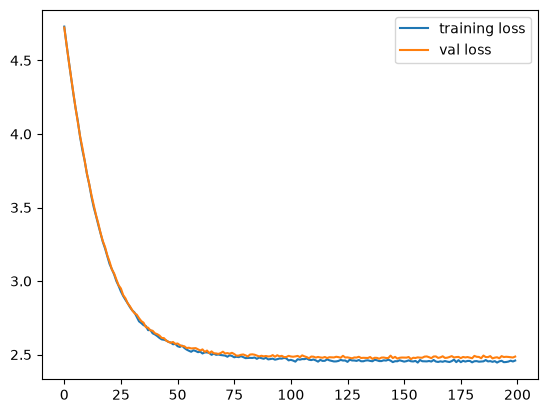

In [34]:
plt.plot(train_losses, label="training loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.show()

In [38]:
print("train loss:", train_losses[-1].item())
print("val loss:", val_losses[-1].item())

train loss: 2.459432363510132
val loss: 2.4864656925201416


In [44]:
print(decode(model.generate(idx=torch.zeros((1, 1), dtype=torch.long), max_new_tokens=200)[0].tolist()))


NGeesonof lat.
ed, Courbed winait nve tl pucore.
Fr ty Het muse h Buroursmy, y,
DULULIORIOluse gigex aitas
It beeler.
ICICUTUShe!
Myororthoyo Oxis yoourist ghekioghafue Moulid dedonorcher heepested y 


## The mathematical trick in self-attention
Goal: we want to calculate the average values of all chars before and including the current char, and we want to do that efficiently.

In [78]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0, 10, (3, 2)).float()
c = a @ b
print("a=")
print(a)
print("--")
print("b=")
print(b)
print("--")
print("c=")
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [121]:
# consider the following toy example:

torch.manual_seed(1337)
B, T, C = 4, 8, 2  # batch, time, channels
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

### Version 1: Naive for-loop

In [122]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B, T, C))
for b in range(B):
    for t in range(T):
        xprev = x[b, : t + 1]  # (t,C)
        xbow[b, t] = torch.mean(xprev, 0)

### Version 2: Matrix Mult

In [125]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x  # (B, T, T) @ (B, T, C) ----> (B, T, C)
print("weight matrix:\n", wei)

weight matrix:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


### Version 3: Softmax

In [126]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
print("weight matrix:\n", wei)

weight matrix:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


In [114]:
print(torch.allclose(xbow, xbow2, atol=1e-7))
print(torch.allclose(xbow, xbow3, atol=1e-7))

True
True


### Version 4: self-attention

$$\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

In [131]:
# single Head
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)  # (B, T, 16)
q = query(x)  # (B, T, 16)
wei = q @ k.transpose(dim0=-2, dim1=-1)  # (B, T, 16) @ (B, 16, T) -> (B, T, T)

tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float("-inf"))  # decoder behavior
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v

In [142]:
print("weight matrix (batch 1):\n", wei[0])

weight matrix (batch 1):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5599, 0.4401, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3220, 0.2016, 0.4764, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1640, 0.0815, 0.2961, 0.4585, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2051, 0.3007, 0.1894, 0.1808, 0.1241, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1273, 0.0291, 0.0169, 0.0552, 0.7114, 0.0000, 0.0000],
        [0.1408, 0.1025, 0.1744, 0.2038, 0.1690, 0.0669, 0.1426, 0.0000],
        [0.0223, 0.1086, 0.0082, 0.0040, 0.0080, 0.7257, 0.0216, 0.1016]],
       grad_fn=<SelectBackward0>)


why divide by $\sqrt{d_k}$ ? - better initialization, weight values have variance = ~1

otherwise the weight values (the matrix mult of Q and K) becomes too peaky, softmax() converges to one-hot

In [151]:
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [152]:
k.var(), q.var(), wei.var()

(tensor(0.9290), tensor(1.0932), tensor(0.9224))

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

### LayerNorm
- BatchNorm normalizes across the **batch** dimension for each feature.
- LayerNorm normalizes across the **feature** dimension for each feature.

In [6]:
class LayerNorm1d:  # (used to be BatchNorm1d)
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

    def __call__(self, x):
        # calculate the forward pass
        xmean = x.mean(1, keepdim=True)  # batch mean
        xvar = x.var(1, keepdim=True)  # batch variance
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100)  # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

## Full training code

![alt text](architecture.svg)

In [74]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt  # for making figures

In [75]:
# hyperparameters
batch_size = 16  # how many independent sequences will we process in parallel?
block_size = 32  # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0

In [ ]:
# read it in to inspect it
with open("../data/shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [77]:
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [78]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)

# create a mapping from characters to integers
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]  # encoder: take a string, output a list of integers
decode = lambda l: "".join([itos[i] for i in l])  # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))  # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [79]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [80]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size):
        super().__init__()
        self.head_size = head_size

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # (batch, time, channel) = (batch_size, block_size, n_embd)
        k = self.key(x)  # (B, T, head_size)
        q = self.query(x)  # (B,T, head_size)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * self.head_size**-0.5  # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # (B, T, T)
        wei = F.softmax(wei, dim=-1)  # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x)  # (B, T, head_size)
        out = wei @ v  # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    """multiple heads of self-attention in parallel"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [81]:
class FeedFoward(nn.Module):
    """a simple linear layer followed by a non-linearity"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [82]:
class Block(nn.Module):
    """Transformer block: communication followed by computation"""

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.ln1 = nn.LayerNorm(n_embd)
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedFoward(n_embd)

    def forward(self, x):
        # residual connections
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [90]:
# super simple bigram model
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)  # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx)  # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T,C)
        x = tok_emb + pos_emb  # (B,T,C)
        x = self.blocks(x)  # (B,T,C)
        x = self.ln_f(x)  # (B,T,C)
        logits = self.lm_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :]  # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
        return idx

0.209729 M parameters


100%|██████████| 5000/5000 [02:20<00:00, 35.68it/s]


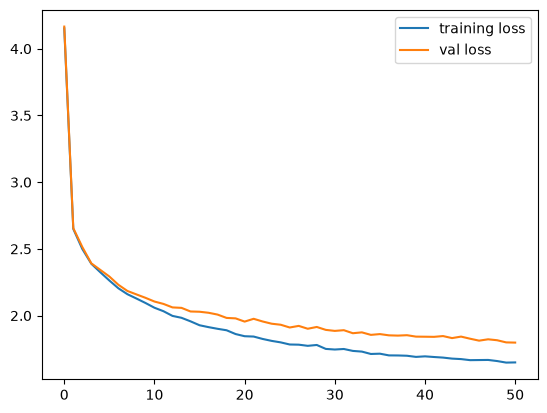

In [58]:
model = BigramLanguageModel()
m = model.to(device)

# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters()) / 1e6, "M parameters")

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
for iter in tqdm(range(max_iters)):
    # sample a batch of data
    xb, yb = get_batch("train")

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])

plt.plot(train_losses, label="training loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.show()

In [59]:
print("train loss:", train_losses[-1].item())
print("val loss:", val_losses[-1].item())

train loss: 1.6491354703903198
val loss: 1.7976771593093872


In [60]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))



KING RICHARD II:
Shall by be madies, bube to take rudes that hangs:
Whith full him truble dilthose, away, my facestanue of me
Youth make is heart milded;
Whice mire, send, night Hereviove that in me now on trabse. Anling tear.

KING RICHARD II:
I am speak you love's norm patelates
Most you, like a laont-now what evily o' a most rivish enceed
And Like the reshep and thrue! A son; ink the flowfey.

PULIET:
Madarry, I have rady, be!

QUEEN ELI:
day Waring's statuin cour accanny vry to change clown, no to to be griefs.

WARWICK:
Is no chense of your grance tords.

DUKING Edward not us, I have much freedy should soubm my issue that was trove
Indeed me over a mouth cates's counted; boy
Or turde sire fear tall: the gold grack nights, low ye need out
Dight hobeaves againce's cowar so! why liels mander so lack.

Privy, my sodons,-his his king.

GLOUCESTER:
Wherefore is of thus dend now the subge lip you on what those the siles,
Becold man carely, more is creward, time to the setic;
To know ou

## Exercises

### EX1
The n-dimensional tensor mastery challenge: Combine the `Head` and `MultiHeadAttention` into one class that processes all the heads in parallel, treating the heads as another batch dimension (answer is in nanoGPT).

In [87]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, head_size):
        super().__init__()
        self.n_head = n_head
        self.head_size = head_size

        self.keys = nn.Linear(n_embd, n_head * head_size, bias=False)
        self.queries = nn.Linear(n_embd, n_head * head_size, bias=False)
        self.values = nn.Linear(n_embd, n_head * head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout1 = nn.Dropout(dropout)

        self.proj = nn.Linear(n_head * head_size, n_embd)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.keys(x)  # (B, T, n_head * head_size)
        q = self.queries(x)  # (B, T, n_head * head_size)

        q = q.view(B, T, self.n_head, self.head_size).transpose(1, 2)  # (B, n_head, T, head_size)
        k = k.view(B, T, self.n_head, self.head_size).transpose(1, 2)  # (B, n_head, T, head_size)

        # affinities, multihead
        # (B, n_head, T, head_size) @ (B, n_head, head_size, T) -> (B, n_head, T, T)
        wei = q @ k.transpose(-2, -1) * self.head_size**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # (B, n_head, T, T)
        wei = F.softmax(wei, dim=-1)  # (B, n_head, T, T)
        wei = self.dropout1(wei)

        # weighted aggregation
        v = self.values(x)  # (B, T, n_head * head_size)
        v = v.view(B, T, self.n_head, self.head_size).transpose(1, 2)  # (B, n_head, T, head_size)
        out = wei @ v  # (B, n_head, T, T) @ (B, n_head, T, head_size) -> (B, n_head, T, head_size)

        out = out.transpose(1, 2).contiguous().view(B, T, self.n_head * self.head_size)  # (B, T, n_head * head_size)
        out = self.dropout2(self.proj(out))
        return out

0.209729 M parameters


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [01:16<00:00, 65.37it/s] 


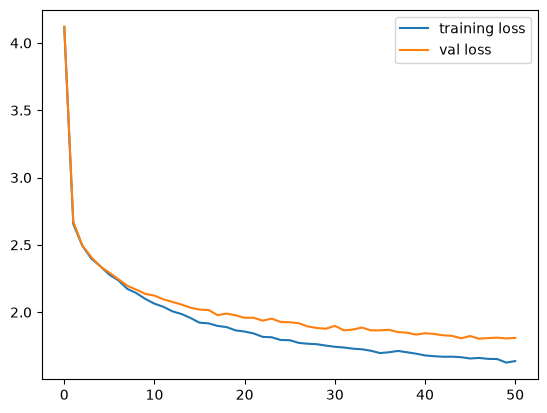

In [88]:
model = BigramLanguageModel()
m = model.to(device)

# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters()) / 1e6, "M parameters")

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
for iter in tqdm(range(max_iters)):
    # sample a batch of data
    xb, yb = get_batch("train")

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])


plt.plot(train_losses, label="training loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.show()

more computationally efficient

In [89]:
print("train loss:", train_losses[-1].item())
print("val loss:", val_losses[-1].item())

train loss: 1.6366488933563232
val loss: 1.809119701385498


### EX2
Train the GPT on your own dataset of choice! What other data could be fun to blabber on about? (A fun advanced suggestion if you like: train a GPT to do addition of two numbers, i.e. a+b=c. You may find it helpful to predict the digits of c in reverse order, as the typical addition algorithm (that you're hoping it learns) would proceed right to left too. You may want to modify the data loader to simply serve random problems and skip the generation of train.bin, val.bin. You may want to mask out the loss at the input positions of a+b that just specify the problem using y=-1 in the targets (see CrossEntropyLoss ignore_index). Does your Transformer learn to add? Once you have this, swole doge project: build a calculator clone in GPT, for all of +-*/. Not an easy problem. You may need Chain of Thought traces.)


addition only

In [ ]:
import random, torch

In [135]:
chars = "0123456789+=\n"
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]  # encoder: take a string, output a list of integers
decode = lambda l: "".join([itos[i] for i in l])  # decoder: take a list of integers, output a string

vocab_size = len(chars)
print("vocab_size:", vocab_size)

vocab_size: 13


In [127]:
max_digits = 2
a = random.randint(0, 10**max_digits - 1)
b = random.randint(0, 10**max_digits - 1)
c = a + b

prob = f"{a}+{b}="  # the GIVEN problem
print("sample:", prob + str(c))

ans = str(c)[::-1] + "\n"  # answer reversed + stop token
seq = prob + ans
print("reverse:", seq)

ids = [stoi[ch] for ch in seq]
print("encode:", ids)

sample: 92+0=92
reverse: 92+0=29

encode: [9, 2, 10, 0, 11, 2, 9, 12]


In [142]:
def make_example(max_digits, T):
    a = random.randint(0, 10**max_digits - 1)
    b = random.randint(0, 10**max_digits - 1)
    c = a + b

    prob = f"{a}+{b}="  # the GIVEN problem
    ans = str(c)[::-1] + "\n"  # answer reversed + stop token

    seq = prob + ans

    ids = encode(seq)

    pad = stoi["\n"]
    if len(ids) < T:
        ids = ids + [pad] * (T - len(ids))  # pad to block_size
    ids = ids[:T]

    p = len(prob)  # answer region starts at index p
    x = torch.tensor(ids, dtype=torch.long)
    y = torch.full((T,), -1, dtype=torch.long)  # -1 = ignore
    for i in range(T - 1):
        j = i + 1  # next char this position must predict
        if j < len(seq) and j >= p:  # only supervise answer/stop chars
            y[i] = ids[j]
    return x, y

In [159]:
max_digits = 2
block_size = 10
x, y = make_example(max_digits, block_size)

for t in range(T):
    context = decode(x[: t + 1].tolist())
    target = y[t]
    print(f"when input is {context} the target: {target}")

print("")

for t in range(T):
    context = x[: t + 1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is 6 the target: -1
when input is 60 the target: -1
when input is 60+ the target: -1
when input is 60+6 the target: -1
when input is 60+64 the target: -1
when input is 60+64= the target: 4
when input is 60+64=4 the target: 2
when input is 60+64=42 the target: 1
when input is 60+64=421 the target: 12
when input is 60+64=421
 the target: -1

when input is tensor([6]) the target: -1
when input is tensor([6, 0]) the target: -1
when input is tensor([ 6,  0, 10]) the target: -1
when input is tensor([ 6,  0, 10,  6]) the target: -1
when input is tensor([ 6,  0, 10,  6,  4]) the target: -1
when input is tensor([ 6,  0, 10,  6,  4, 11]) the target: 4
when input is tensor([ 6,  0, 10,  6,  4, 11,  4]) the target: 2
when input is tensor([ 6,  0, 10,  6,  4, 11,  4,  2]) the target: 1
when input is tensor([ 6,  0, 10,  6,  4, 11,  4,  2,  1]) the target: 12
when input is tensor([ 6,  0, 10,  6,  4, 11,  4,  2,  1, 12]) the target: -1


In [173]:
def get_batch(batch_size, T, max_digits):
    xs, ys = zip(*[make_example(max_digits, T) for _ in range(batch_size)])
    x = torch.stack(xs)
    y = torch.stack(ys)
    return x.to(device), y.to(device)

In [161]:
batch_size = 16
xs, ys = get_batch(batch_size, block_size, max_digits)
xs.shape, ys.shape

(torch.Size([16, 10]), torch.Size([16, 10]))

In [186]:
max_digits = 2
batch_size = 16
block_size = 10
max_iters = 10000
eval_interval = 100
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 100
n_embd = 16
n_head = 4
n_layer = 2
dropout = 0.0

In [187]:
@torch.no_grad()
def eval_accuracy(n=eval_iters):
    correct = 0
    hi = 10**max_digits  # same range the model was trained on
    for _ in range(n):
        a = torch.randint(0, hi, (1,)).item()
        b = torch.randint(0, hi, (1,)).item()
        prompt = encode(f"{a}+{b}=")
        out = model.generate(torch.tensor(prompt).unsqueeze(0).to(device), max_new_tokens=10)[0]
        pred = decode(out[len(prompt) :].tolist()).strip("\n")
        try:
            if int(pred[::-1]) == a + b:  # reverse back
                correct += 1
        except:
            pass
    return correct / n


@torch.no_grad()
def estimate_loss():
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        X, Y = get_batch(batch_size, block_size, max_digits)
        X, Y = X.to(device), Y.to(device)
        logits, loss = model(X, Y)
        losses[k] = loss.item()
    out = losses.mean()
    model.train()
    return out

In [188]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size):
        super().__init__()
        self.head_size = head_size

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # (batch, time, channel) = (batch_size, block_size, n_embd)
        k = self.key(x)  # (B, T, head_size)
        q = self.query(x)  # (B,T, head_size)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * self.head_size**-0.5  # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # (B, T, T)
        wei = F.softmax(wei, dim=-1)  # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x)  # (B, T, head_size)
        out = wei @ v  # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    """multiple heads of self-attention in parallel"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedFoward(nn.Module):
    """a simple linear layer followed by a non-linearity"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class FeedFoward(nn.Module):
    """a simple linear layer followed by a non-linearity"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Transformer block: communication followed by computation"""

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.ln1 = nn.LayerNorm(n_embd)
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedFoward(n_embd)

    def forward(self, x):
        # residual connections
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


# super simple bigram model
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)  # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx)  # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T,C)
        x = tok_emb + pos_emb  # (B,T,C)
        x = self.blocks(x)  # (B,T,C)
        x = self.ln_f(x)  # (B,T,C)
        logits = self.lm_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets, ignore_index=-1)  # <- ignore y=-1

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :]  # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
            # break if answer is outputed
            if idx_next.item() == stoi["\n"]:
                break
        return idx

0.007085 M parameters


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [02:48<00:00, 59.19it/s]


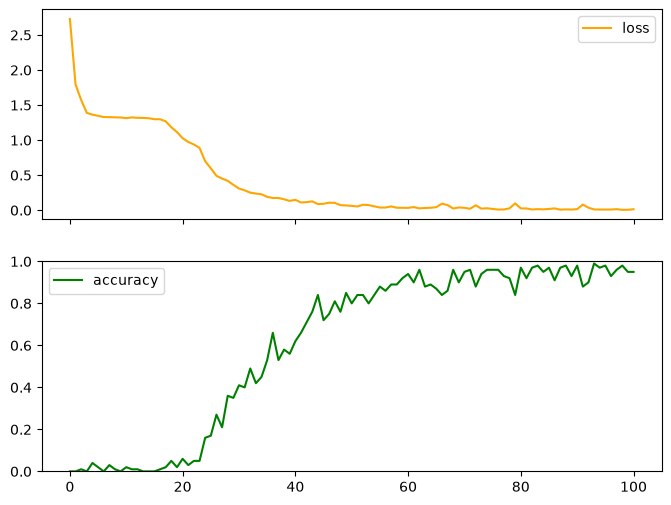

In [189]:
model = BigramLanguageModel()
m = model.to(device)

# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters()) / 1e6, "M parameters")

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

losses = []
accs = []
for iter in tqdm(range(max_iters)):
    # sample a batch of data
    xb, yb = get_batch(batch_size, block_size, max_digits)

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        l = estimate_loss()
        a = eval_accuracy()
        losses.append(l)
        accs.append(a)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(losses, label="loss", color="orange")
ax1.legend()
ax2.plot(accs, label="accuracy", color="green")
ax2.set_ylim(0, 1)
ax2.legend()
plt.show()

In [190]:
print("loss:", losses[-1].item())
print("accuray:", accs[-1])

loss: 0.013781685382127762
accuray: 0.95


In [220]:
correct = 0
n = 20
hi = 10**max_digits  # same range the model was trained on
for _ in range(n):
    a = torch.randint(0, hi, (1,)).item()
    b = torch.randint(0, hi, (1,)).item()
    prompt = encode(f"{a}+{b}=")
    print("prompt:", f"{a}+{b}= ?", end=" ")
    out = model.generate(torch.tensor(prompt).unsqueeze(0).to(device), max_new_tokens=10)[0]
    pred = decode(out[len(prompt) :].tolist()).strip("\n")
    ans = pred[::-1]
    print("model:", ans)
    if int(ans) == a + b:  # reverse back
        correct += 1

print("accuracy", correct / n)

prompt: 80+26= ? model: 106
prompt: 38+81= ? model: 119
prompt: 16+80= ? model: 96
prompt: 34+67= ? model: 101
prompt: 79+54= ? model: 133
prompt: 82+63= ? model: 145
prompt: 43+33= ? model: 76
prompt: 89+15= ? model: 104
prompt: 92+37= ? model: 129
prompt: 23+0= ? model: 23
prompt: 70+11= ? model: 81
prompt: 5+18= ? model: 23
prompt: 42+25= ? model: 67
prompt: 34+51= ? model: 85
prompt: 22+35= ? model: 57
prompt: 30+43= ? model: 73
prompt: 64+19= ? model: 83
prompt: 84+93= ? model: 177
prompt: 50+59= ? model: 109
prompt: 97+7= ? model: 104
accuracy 1.0


### EX3

Find a dataset that is very large, so large that you can't see a gap between train and val loss. Pretrain the transformer on this data, then initialize with that model and finetune it on tiny shakespeare with a smaller number of steps and lower learning rate. Can you obtain a lower validation loss by the use of pretraining?


### EX4
Read some transformer papers and implement one additional feature or change that people seem to use. Does it improve the performance of your GPT?